<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/iui2026-xai/blockies_v2_xai_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blockies Dataset


In [1]:
import pathlib
import os
import sys
from pathlib import Path
import tarfile
import random
import zipfile

import numpy as np

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18'

# Setup and Load Datasets

In [3]:
# data downloading and dataset utilities

def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

## Load Dataset and Dataloaders


## Load XAI Study Data

In [4]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [5]:
study_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

study_dir = download_file(url=study_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='data', # change this if not using Colab
                          extract=True,
                          force_download=True,
                          archive_folder=zip_name)
study_dir

100%|██████████| 7.81M/7.81M [00:00<00:00, 9.57MB/s]

File downloaded to: data/study_samples.zip
Extracting zip file...
File extracted to: data


PosixPath('data/study_samples')

In [6]:
# load and preprocess dataframes
main_dir = study_dir / 'main_data/xai_samples'
tutorial_dir = study_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df.csv')
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

In [7]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])


study_dataset = ImageDataset(study_df, main_dir, transform=transform)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=6, pin_memory=True)

tutorial_dataset = ImageDataset(tutorial_df, tutorial_dir, transform=transform)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=6, pin_memory=True)

# Model Loading and Evaluation





In [8]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [9]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    preds = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    print(f"Evaluation Loss: {avg_loss:.4f}, Evaluation Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, np.array(preds)

In [10]:
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/J2d1z9V5wQGGR8X/download',
                                file_name='best_model.pth',
                                cache_dir=f'model/{modeltype}_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=False)
checkpoint_path

File already exists at: model/resnet18_checkpoint/best_model.pth


PosixPath('model/resnet18_checkpoint/best_model.pth')

In [11]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Check predictions on datasets

Sanity check to ensure the model is the correct one

- The main study dataset should have 80% accuracy.
- The tutorial dataset should have 60% accuracy.

In [12]:
# load best model and evaluate
model = load_resnet18(num_classes=len(CLASSES),
                      pretrained=False,
                      checkpoint_path=checkpoint_path)
model.to(device)

_, _, study_preds = evaluate_model(model, study_dataloader, criterion, device)
_, _, tutorial_preds = evaluate_model(model, tutorial_dataloader, criterion, device)

Loaded random model
Loaded checkpoint from: model/resnet18_checkpoint/best_model.pth
Evaluation Loss: 0.6064, Evaluation Accuracy: 0.8000
Evaluation Loss: 0.9999, Evaluation Accuracy: 0.6000


In [13]:
# compare to saved accuracies
(study_df['pred'] == study_df['ill']).mean(), (tutorial_df['pred'] == tutorial_df['ill']).mean()

(0.8, 0.6)

In [14]:
# assert that all predictions are the same
assert (study_preds == study_df['pred']).all(), 'Study predictions are incorrect'
assert (tutorial_preds == tutorial_df['pred']).all(), 'Tutorial predictions are incorrect '

print('All predictions for each dataset are equal. This is the correct model')

All predictions for each dataset are equal. This is the correct model


# View Data

In [15]:
# display the widest dataframe
# This will show all columns of the DataFrame without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
study_df.head(2) 

,Unnamed: 0,obj_name,num_ill_chars,ill_chars,labeling_error,main_spherical,sec_spherical,sec_bones,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,arm_position,obj_color,obj_color_rgba,bg_color,bg_color_rgba,resolution,id,original_id,_attributes_status,label,__module__,__name__,filename,ill,sphere_diff,num_sec_bones,pred,main_spherical_pred,sec_spherical_pred,bending_pred,arm_position_pred,num_sec_bones_pred,obj_rotation_roll_pred,obj_rotation_pitch_pred,obj_rotation_yaw_pred,position_x_pred,position_y_pred,obj_color_pred,bg_color_pred,concept_pred,ill_label,pred_label
0,320,healthy,0,[],False,0.013151,0.343460,110,0.012181,0.344598,-0.511440,-2.008321,False,-0.697111,-0.651274,0.355950,0.246182,"[0.5488761722823521, 0.6851035851764701, 0.994...",0.834853,"[0.9057834780117641, 0.45518569216470506, 0.35...","[256, 256]",cec708b5-2af1-454b-a0c8-8c8047565127,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,cec708b5-2af1-454b-a0c8-8c8047565127.png,0,0.330310,2,0,0.048011,0.324341,0.020773,0.349298,2.069187,0.012781,-0.495818,-1.985869,-0.716843,-0.620908,0.226300,0.847573,0,Healthy,Healthy
1,1022,healthy,1,[stretchy],False,0.057501,0.438306,110,0.087594,-0.292657,0.623956,-0.933327,False,-0.745413,-0.725040,0.532666,0.316982,"[0.6461128107647051, 0.764436496529411, 0.9968...",0.440212,"[0.8006008472941171, 0.8503583215607841, 0.930...","[256, 256]",33f21483-6240-4fd5-95bc-36be485b3259,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,33f21483-6240-4fd5-95bc-36be485b3259.png,0,0.380805,2,0,0.090473,0.435559,0.103601,0.455025,1.975521,-0.010562,0.513205,-0.798173,-0.729212,-0.609363,0.325815,0.454940,0,Healthy,Healthy


In [16]:
# Get the unique values in the 'ill_chars' column
unique_ill_chars = study_df['ill_chars'].explode().unique()
print("Unique values in 'ill_chars':", unique_ill_chars)

ill = study_df['ill'].explode().unique()
print("Unique values in 'ill':", ill)

Unique values in 'ill_chars': [nan 'stretchy' 'high_sphere_diff' 'high_bend' 'mutation_mainbones']
Unique values in 'ill': [0 1]


## Main Study Dataset

In [17]:
study_img_paths = study_df['filename'].apply(lambda x: os.path.join(main_dir, x)).tolist()
tutorial_img_paths = tutorial_df['filename'].apply(lambda x: os.path.join(tutorial_dir, x)).tolist()

study_imgs = [Image.open(path).convert('RGB') for path in study_img_paths]
tutorial_imgs = [Image.open(path).convert('RGB') for path in tutorial_img_paths]

# Generate Explanations

### 4-  LRP XAI

In [18]:

from zennit.rules import Epsilon
from zennit.image import imgify

from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat, EpsilonAlpha2Beta1Flat # EpsilonPlusFlat

In [19]:
preds = torch.tensor(study_df['pred'].values, dtype=torch.long)
targets = F.one_hot(preds, num_classes=len(CLASSES)).float().to('cpu')

targets.shape, preds.shape

(torch.Size([40, 2]), torch.Size([40]))

In [20]:
model.to('cpu')

with Gradient(model=model, composite=EpsilonAlpha2Beta1Flat(canonizers=[ResNetCanonizer()])) as attributor:
  inp = [transform(img) for img in study_imgs]
  inp = torch.stack(inp)
  
  inp = inp.to('cpu')
  print(inp.shape)
  
  output, attribution = attributor(inp, targets)

# add model back to gpu (in case used again somewhere else)
model = model.to(device)

torch.Size([40, 3, 256, 256])


In [21]:

def plot_lrp(img, attribution, ax):
  relevance = attribution.sum(0)
  vmax = relevance.abs().max()
  ax.imshow(img)
  ax.imshow(relevance, cmap='bwr', vmin=-vmax, vmax=vmax, alpha=0.80)
  ax.axis('off')

In [22]:
study_np = [np.array(img)/255 for img in study_imgs]
study_np[1].shape

(256, 256, 3)

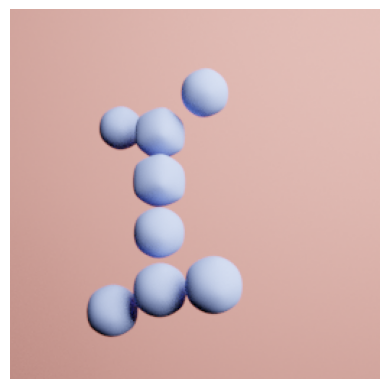

In [23]:
# show the first original image in study_np
plt.imshow(study_np[15])
plt.axis('off')
plt.show()

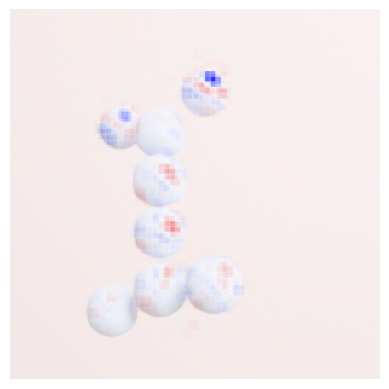

In [24]:
plot_lrp(study_np[15], attribution[15], ax=plt.gca())

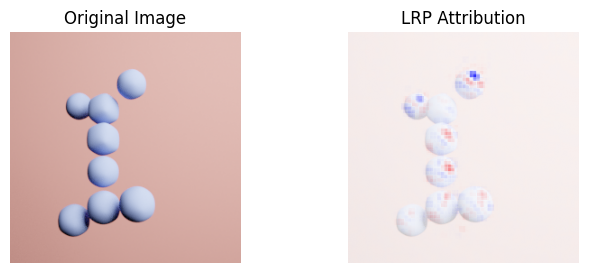

In [25]:
# plot the above two plots together
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plot_lrp(study_np[15], attribution[15], ax[1])
ax[1].set_title('LRP Attribution')
ax[0].imshow(study_np[15])
ax[0].axis('off')
ax[0].set_title('Original Image')
plt.show()